In [ ]:
!pip install ISLP

In [ ]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
from statsmodels.datasets import get_rdataset
import sklearn.model_selection as skm
from sklearn.model_selection import train_test_split,GridSearchCV
from ISLP import load_data , confusion_table
from ISLP.models import ModelSpec as MS

In [ ]:
from sklearn.tree import (DecisionTreeClassifier as DTC,
DecisionTreeRegressor as DTR,
plot_tree,export_text)
from sklearn.metrics import (accuracy_score, roc_auc_score,log_loss,mean_squared_error,make_scorer,precision_score)
from sklearn.ensemble import \
(RandomForestRegressor as RF,
GradientBoostingRegressor as GBR)
from ISLP.bart import BART
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from ISLP import load_data
boston=load_data("Boston")
X = boston.drop(columns='medv')
y = boston['medv']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=8)



In [ ]:
### Linear Regression ###
lm = LinearRegression()
lm.fit(X_train, y_train)
lm_pred = lm.predict(X_test)
mse_lm = mean_squared_error(y_test, lm_pred)
print(f"Linear Regression MSE: {mse_lm:.4f}")

Linear Regression MSE: 26.7580


In [ ]:
model = MS(boston.columns.drop('medv'), intercept=False)
D = model.fit_transform(boston)
feature_names = list(D.columns)
X = np.asarray(D)

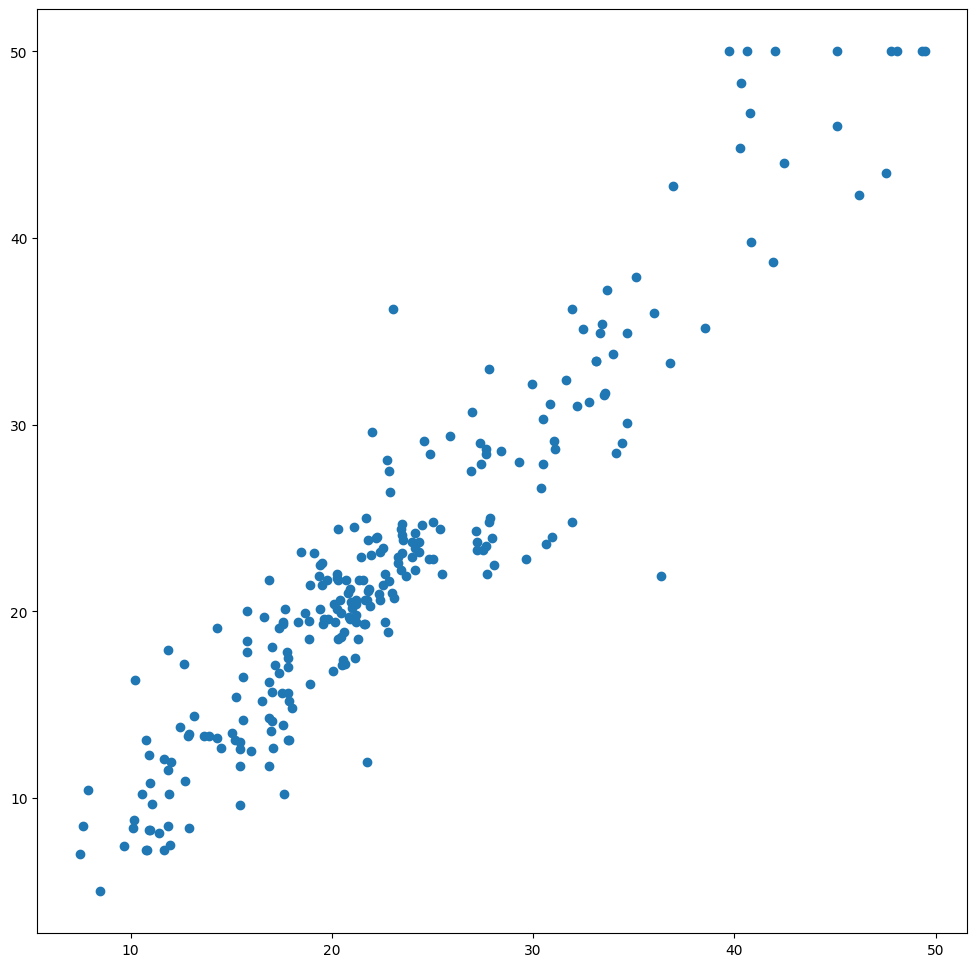

In [ ]:
#  boost regression tree
boost_boston = GBR(n_estimators=5000,
learning_rate =0.001,
max_depth=3,
random_state=0)
boost_boston.fit(X_train , y_train)

y_hat_bag = boost_boston.predict(X_test)
ax = subplots(figsize=(12,12))[1]
ax.scatter(y_hat_bag , y_test)

In [ ]:
mse_tree_boost = mean_squared_error(y_test, y_hat_bag)
print(f"boost Tree MSE: {mse_tree_boost:.4f}")

boost Tree MSE: 10.8943


In [ ]:
# change some parameters
boost_boston = GBR(n_estimators=5000,
learning_rate =0.1,
max_depth=3,
random_state=0).fit(X_train , y_train)

y_hat_boost = boost_boston.predict(X_test)
mse_boost_bag = mean_squared_error(y_test, y_hat_boost)
print(f"bagged Tree MSE: {mse_boost_bag:.4f}")


bagged Tree MSE: 10.2855


In [ ]:
feature_imp = pd.DataFrame(
{'importance':boost_boston.feature_importances_},
index=feature_names)
feature_imp.sort_values(by='importance', ascending=False)

,importance
lstat,0.547441
rm,0.235744
dis,0.069920
ptratio,0.035730
age,0.034471
crim,0.031643
nox,0.027276
tax,0.009105
indus,0.003657
rad,0.003361


<ipython-input-11-ff04123793bf>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances, y=features, palette='viridis')


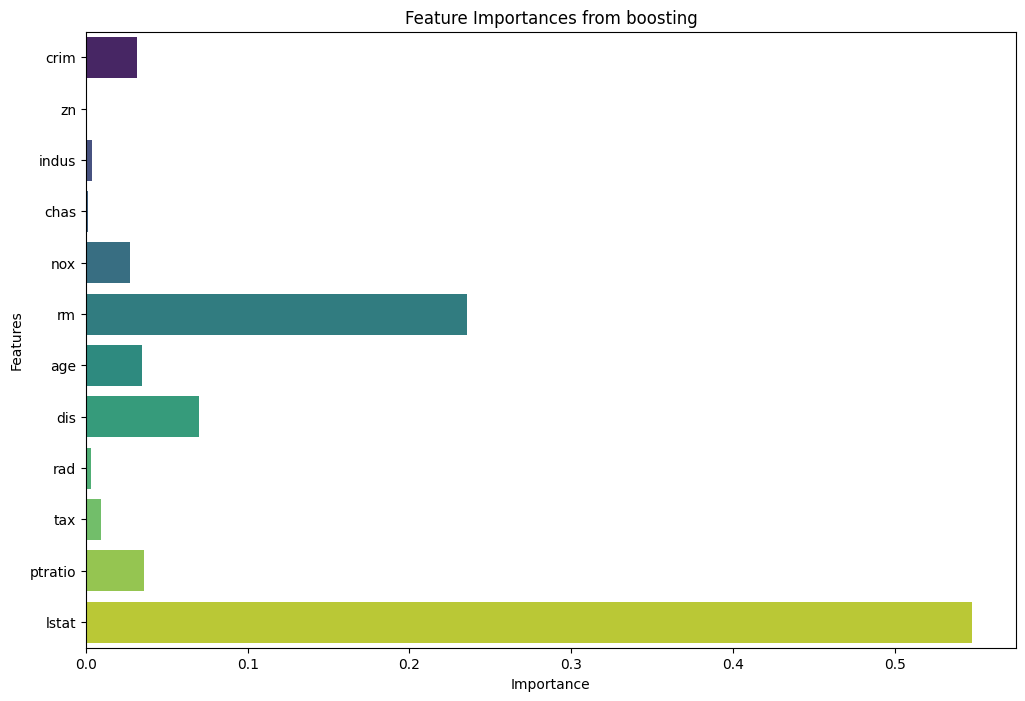

In [ ]:
feature_importances = boost_boston.feature_importances_
features = feature_names

plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances, y=features, palette='viridis')
plt.title('Feature Importances from boosting')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

In [ ]:
# Define hyperparameters grid for Gradient Boosting
param_grid = {
    'n_estimators': [100, 500],            # Number of boosting stages
    'learning_rate': [0.01, 0.1],    # Learning rate (shrinkage)
    'max_depth': [2, 5],               # Maximum depth of each tree
 #   'min_samples_split': [5, 10],          # Minimum samples to split a node
  #  'min_samples_leaf': [4, 6, 8],         # Minimum samples at leaf nodes
    'subsample': [0.8, 1.0],               # Fraction of samples used for fitting each base learner
    'max_features': ['sqrt', 0.5]          # Number of features to consider for the best split
}

# Initialize the Gradient Boosting Regressor
gbr_model = GBR(random_state=0)

# Define GridSearchCV
grid_search = GridSearchCV(estimator=gbr_model,
                           param_grid=param_grid,
                           scoring='neg_mean_squared_error',  # Use MSE as the scoring metric
                           cv=5,  # 5-fold cross-validation
                           n_jobs=-1,  # Use all available processors
                           verbose=1)

# Fit GridSearchCV on the training data
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print(f"Best Hyperparameters: {best_params}")


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'max_features': 0.5, 'n_estimators': 100, 'subsample': 1.0}


In [ ]:

# Get the best estimator
best_gbr_model = grid_search.best_estimator_

# Use the best model to predict on the test set
y_pred_best_gbr = best_gbr_model.predict(X_test)

# Calculate the mean squared error of the best model
from sklearn.metrics import mean_squared_error
mse_best_gbr = mean_squared_error(y_test, y_pred_best_gbr)
print(f"Mean Squared Error with Best Hyperparameters: {mse_best_gbr:.4f}")



Mean Squared Error with Best Hyperparameters: 11.6360


In [ ]:
# Load the Caravan dataset
caravan = load_data("Caravan")

# Prepare features and target
X_caravan = caravan.drop(columns='Purchase')
y_caravan = caravan['Purchase']

# Encode the target variable
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_caravan)  # Converts 'No' -> 0 and 'Yes' -> 1

# Train-Test split using train_test_split
X_train_caravan, X_test_caravan, y_train_caravan, y_test_caravan = train_test_split(
    X_caravan, y_encoded, test_size=0.5, random_state=8)


In [ ]:
#  bagged classification tree
boost_boston = GBR(n_estimators=1000,
learning_rate =0.001,
max_depth=3,
random_state=0)
boost_boston.fit(X_train_caravan, y_train_caravan)

y_hat_bag = boost_boston.predict(X_test_caravan)
print(y_hat_bag)

[0.04108919 0.04503955 0.0892838  ... 0.09660542 0.03094436 0.03094436]


In [ ]:
y_hat_bag1 = (y_hat_bag > 0.5).astype(int)
test_accuracy =accuracy_score(y_test_caravan, y_hat_bag1)
print(f"Test set accuracy of the boosting: {test_accuracy:.4f}")
confusion = confusion_table(y_hat_bag1,y_test_caravan)
confusion

Test set accuracy of the boosting: 0.9419


Truth,0,1
Predicted,,
0,2742,169
1,0,0


In [ ]:
# Calculate the AUC
auc_score = roc_auc_score(y_test_caravan, y_hat_bag)
print(f"AUC Score: {auc_score:.4f}")

AUC Score: 0.7389


In [ ]:
###cross-validation###
# Define hyperparameters grid for Gradient Boosting
param_grid = {
    'n_estimators': [1000],            # Number of boosting stages
    'learning_rate': [0.001, 0.01],    # Learning rate (shrinkage)
    'max_depth': [1, 2],               # Maximum depth of each tree
 #   'min_samples_split': [5, 10],          # Minimum samples to split a node
  #  'min_samples_leaf': [4, 6, 8],         # Minimum samples at leaf nodes
   # 'subsample': [0.8, 1.0],               # Fraction of samples used for fitting each base learner
    'max_features': ['sqrt', 0.5]          # Number of features to consider for the best split
}

# Initialize the Gradient Boosting Regressor
gbr_model = GBR(random_state=0)

# Define GridSearchCV
grid_search = GridSearchCV(estimator=gbr_model,
                           param_grid=param_grid,
                           scoring='accuracy',  #
                           cv=5,  # 5-fold cross-validation
                           n_jobs=-1,  # Use all available processors
                           verbose=1)

# Fit GridSearchCV on the training data
grid_search.fit(X_train_caravan, y_train_caravan)

# Get the best parameters
best_params = grid_search.best_params_
print(f"Best Hyperparameters: {best_params}")


Fitting 5 folds for each of 8 candidates, totalling 40 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:1103: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan]
  warnings.warn(


Best Hyperparameters: {'learning_rate': 0.001, 'max_depth': 1, 'max_features': 'sqrt', 'n_estimators': 1000}


In [ ]:
# Get the best estimator
best_gbr_model = grid_search.best_estimator_

# Use the best model to predict on the test set
y_pred_best_gbr = best_gbr_model.predict(X_test_caravan)



In [ ]:
y_hat_bag1 = (y_pred_best_gbr > 0.5).astype(int)
test_accuracy =accuracy_score(y_test_caravan, y_hat_bag1)
print(f"Test set accuracy of the pruned tree: {test_accuracy:.4f}")
confusion = confusion_table(y_hat_bag1,y_test_caravan)
confusion

Test set accuracy of the pruned tree: 0.9419


Truth,0,1
Predicted,,
0,2742,169
1,0,0


In [ ]:
auc_score = roc_auc_score(y_test_caravan, y_pred_best_gbr)
print(f"AUC Score: {auc_score:.4f}")

AUC Score: 0.7225
